# Аналитика E-Commerce: Olist Brazilian Dataset

**Цель:** отработать SQL-аналитику на реальном датасете через SQLAlchemy + Pandas.

**Датасет:** [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — 
100 000 заказов с 2016 по 2018 год, 9 связанных таблиц.

**Стек:** Python · SQLAlchemy · SQLite · Pandas · Matplotlib · Seaborn

---

### Структура анализа
1. Подключение и изучение схемы
2. Базовый JOIN
3. Выручка по месяцам
4. Воронка по статусам заказов
5. Скользящее среднее (7 дней)
6. Топ-10 категорий
7. Когортный анализ
8. Рост выручки MoM (LAG)
9. Топ-3 продавца в категории
10. Сводная таблица по категориям
11. Время доставки и рейтинг

In [15]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/terencicp/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite


In [2]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

engine = create_engine('sqlite:////kaggle/input/datasets/terencicp/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite')

def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

## 1. Схема данных

Перед написанием запросов — изучаем что вообще есть в базе.

In [21]:
tables = query("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
""")
print(tables)

                                 name
0   product_category_name_translation
1                             sellers
2                           customers
3                         geolocation
4                         order_items
5                      order_payments
6                       order_reviews
7                              orders
8                            products
9                     leads_qualified
10                       leads_closed


In [29]:
for table in tables["name"]:
    print(f'----------------------------{table}----------------------------')
    print(query(f"""PRAGMA table_info('{table}')"""))
print(f"\nОбщее количество таблиц в датасете: {len(tables['name'])}")

----------------------------product_category_name_translation----------------------------
   cid                           name  type  notnull dflt_value  pk
0    0          product_category_name  TEXT        0       None   0
1    1  product_category_name_english  TEXT        0       None   0
----------------------------sellers----------------------------
   cid                    name     type  notnull dflt_value  pk
0    0               seller_id     TEXT        0       None   0
1    1  seller_zip_code_prefix  INTEGER        0       None   0
2    2             seller_city     TEXT        0       None   0
3    3            seller_state     TEXT        0       None   0
----------------------------customers----------------------------
   cid                      name     type  notnull dflt_value  pk
0    0               customer_id     TEXT        0       None   0
1    1        customer_unique_id     TEXT        0       None   0
2    2  customer_zip_code_prefix  INTEGER        0       N

## 2. Базовый JOIN: География покупателей
Для начала поймем, где находится ядро нашей аудитории. Объединим данные о заказах с профилями клиентов и посмотрим на распределение заказов по штатам Бразилии.

In [40]:
top_states = query("""
    SELECT c.customer_state, COUNT(o.order_id) AS count_orders
    FROM customers AS c
    INNER JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_state
    LIMIT 10
""")
top_states

,customer_state,count_orders
0,AC,81
1,AL,413
2,AM,148
3,AP,68
4,BA,3380
5,CE,1336
6,DF,2140
7,ES,2033
8,GO,2020
9,MA,747


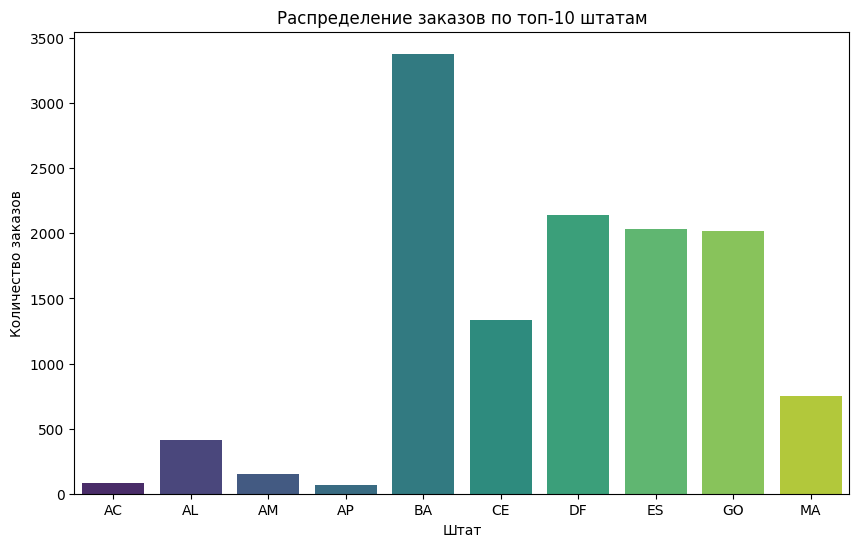

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_states, 
    x='customer_state', 
    y='count_orders', 
    palette='viridis',
    hue='customer_state',  
    legend=False          
)
plt.title("Распределение заказов по топ-10 штатам")
plt.xlabel("Штат")
plt.ylabel("Количество заказов")
plt.show()

**💡 Бизнес-инсайт:** 
Подавляющее большинство клиентов Olist сконцентрировано в штате Сан-Паулу (SP) и соседних южных регионах. Это логично, так как это самая экономически развитая часть Бразилии. Маркетинговые кампании и склады стоит в первую очередь масштабировать именно здесь.

## 3. Динамика выручки по месяцам
Проанализируем общие финансовые показатели маркетплейса. Посчитаем суммарную выручку (стоимость товаров + доставка) в разбивке по месяцам, чтобы оценить общий тренд и сезонность.

In [4]:
progress = query("""
        SELECT strftime('%Y-%m', order_purchase_timestamp) AS order_month, SUM(price + freight_value) AS total_revenue
        FROM orders
        INNER JOIN order_items
            ON orders.order_id = order_items.order_id
        WHERE order_status = 'delivered'
        GROUP BY order_month
        ORDER BY order_month ASC
""")
progress

,order_month,total_revenue
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32
5,2017-03,414330.95
6,2017-04,390812.40
7,2017-05,566851.40
8,2017-06,490050.37
9,2017-07,566299.08


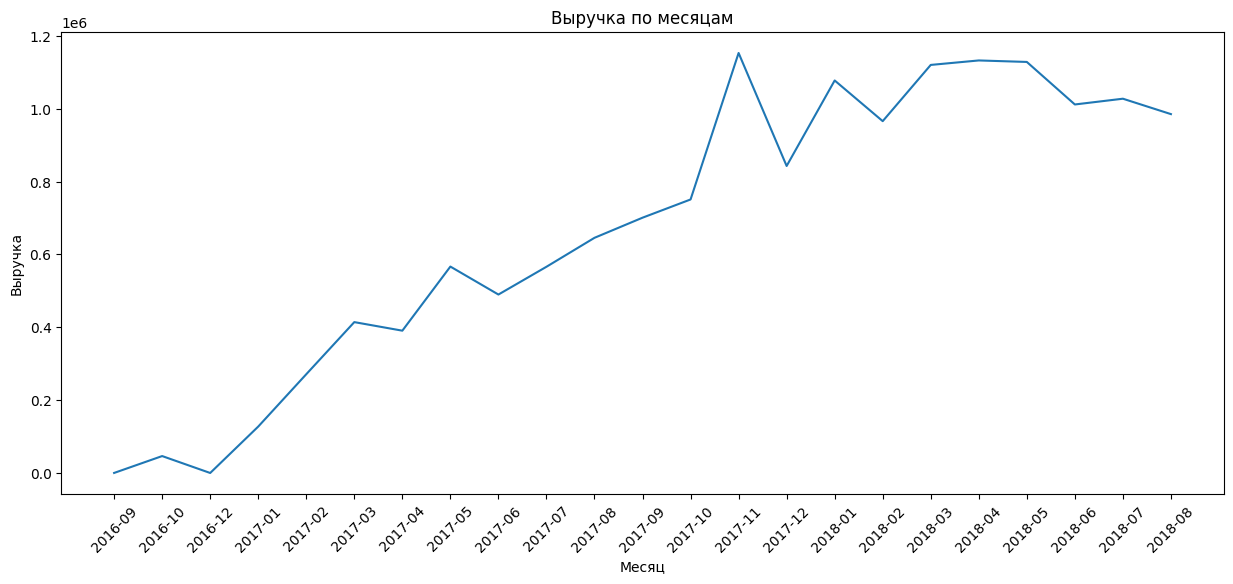

In [9]:
plt.figure(figsize=(15,6))

sns.lineplot(data=progress, x='order_month', y='total_revenue')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.ylabel('Выручка')

plt.show()

**💡 Бизнес-инсайт:** 
Наблюдается ярко выраженный тренд на рост выручки с 2016 по начало 2018 года. Отчетливо виден гигантский пик продаж в ноябре 2017 года — это влияние «Черной пятницы» (Black Friday), главного распродажного события года.

## 4. Воронка статусов заказов
На пути к клиенту заказ проходит несколько стадий: подтверждение, сборка, отправка, доставка. Посмотрим на распределение всех заказов по текущим статусам, чтобы понять, какой процент покупок отменяется или теряется.


In [25]:
statuses = query("""
        SELECT 
            order_status AS status, 
            COUNT(order_id) AS count, 
            ROUND(((COUNT(order_id) * 100 / (SELECT COUNT(order_id) FROM orders))), 2) AS percent
        FROM orders
        GROUP BY order_status
""")
statuses

,status,count,percent
0,delivered,96478,97.0
1,shipped,1107,1.0
2,canceled,625,0.0
3,unavailable,609,0.0
4,invoiced,314,0.0
5,processing,301,0.0
6,created,5,0.0
7,approved,2,0.0


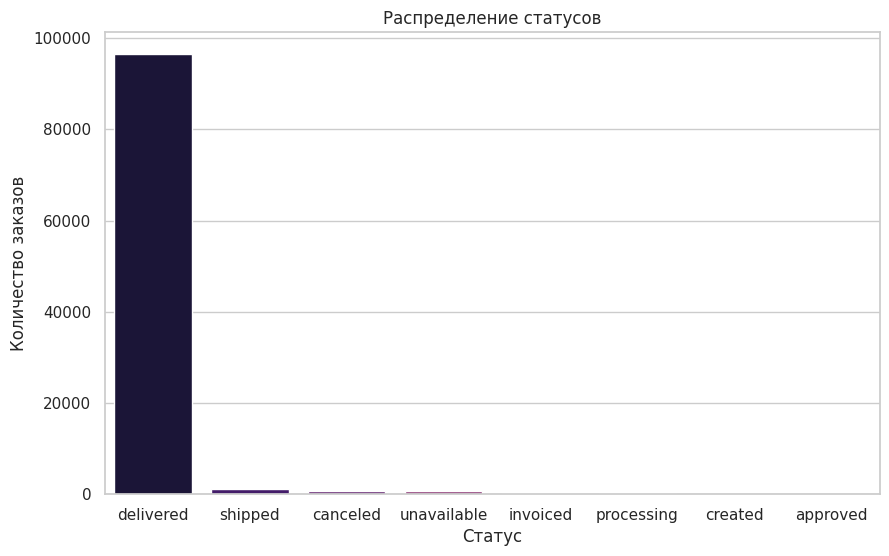

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(data=statuses, x='status', y='count', palette='magma', hue='status', legend=False)
plt.title('Распределение статусов')
plt.xlabel('Статус')
plt.ylabel('Количество заказов')

plt.show()

**💡 Бизнес-инсайт:** 
Более 97% всех заказов успешно доставляются клиентам (`delivered`). Доля отмен (`canceled`) и потерь (`unavailable`) крайне мала, что говорит о хорошо отлаженных логистических и складских процессах маркетплейса.

## 5. Сглаживание колебаний: 7-дневное скользящее среднее
Дневная выручка может сильно скакать из-за выходных и праздников. Чтобы увидеть реальный тренд, рассчитаем 7-дневное скользящее среднее (Moving Average) для ежедневных продаж.


In [40]:
window = query("""
    with sb AS (
        SELECT 
            strftime('%Y-%m-%d', order_purchase_timestamp) AS time, 
            SUM(price + freight_value) AS day_value
        FROM orders
        INNER JOIN order_items
            ON orders.order_id = order_items.order_id
        WHERE order_status = 'delivered'
        GROUP BY time
    )

    SELECT 
        time, 
        day_value,
        AVG(day_value) OVER 
            (ORDER BY time ROWS BETWEEN 6 PRECEDING AND 1 FOLLOWING) 
                AS overage_week
    FROM sb
    ORDER BY time ASC 
""")
window

,time,day_value,overage_week
0,2016-09-15,143.46,351.495000
1,2016-10-03,559.53,3508.136667
2,2016-10-04,9821.42,4433.477500
3,2016-10-05,7209.50,4906.562000
4,2016-10-06,6798.90,5226.211667
...,...,...,...
607,2018-08-25,11737.76,21965.151250
608,2018-08-26,9333.16,18983.290000
609,2018-08-27,6111.61,14613.956250
610,2018-08-28,4121.22,10987.645000


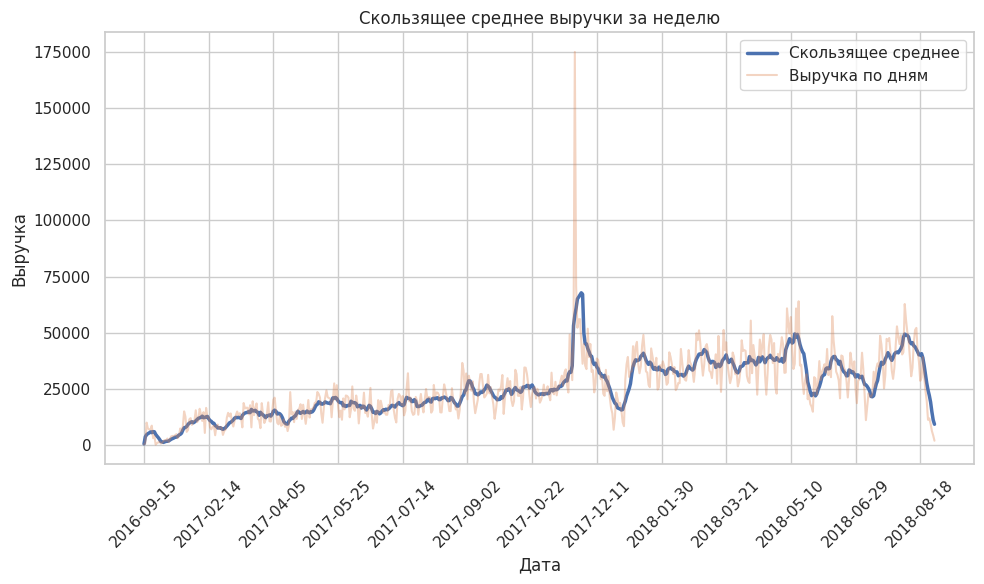

In [43]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))
sns.lineplot(data=window, x='time', y='overage_week', label='Скользящее среднее', linewidth=2.5)
sns.lineplot(data=window, x='time', y='day_value', label='Выручка по дням', alpha=0.35)
plt.title('Скользящее среднее выручки за неделю')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(15)) 
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Топ-10 категорий товаров
Выясним, какие категории товаров приносят платформе больше всего денег. Поскольку оригинальные названия категорий на португальском, нам понадобится таблица переводов.

In [54]:
popular = query("""
        WITH sb AS (
            SELECT orders.order_id, product_id, price
            FROM orders
            INNER JOIN order_items
                ON orders.order_id = order_items.order_id
            WHERE order_status = 'delivered'
        )

        SELECT product_category_name_english AS category, SUM(price) AS total_revenue
        FROM products
        INNER JOIN sb
            ON sb.product_id = products.product_id
        INNER JOIN product_category_name_translation AS pr
            ON pr.product_category_name = products.product_category_name
        GROUP BY category
        ORDER BY total_revenue DESC
        LIMIT 10
""")
popular

,category,total_revenue
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61
5,furniture_decor,711927.69
6,housewares,615628.69
7,cool_stuff,610204.10
8,auto,578966.65
9,toys,471286.48


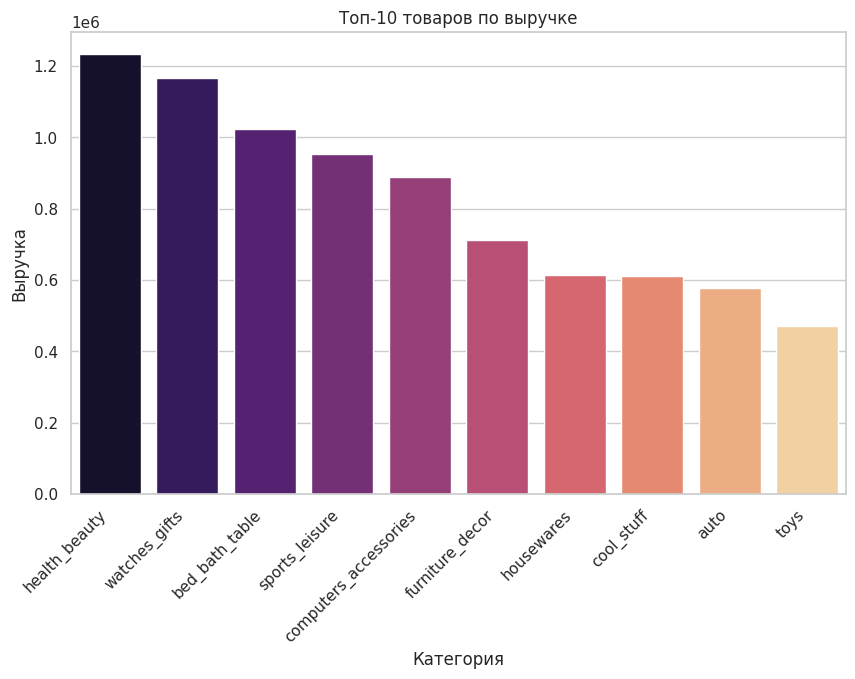

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(data=popular, x='category', y='total_revenue', palette='magma', hue='category', legend=False)
plt.title('Топ-10 товаров по выручке')
plt.xlabel('Категория')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Выручка')
plt.show()

## 7. Когортный анализ (Retention)
Проверим, насколько хорошо платформа удерживает клиентов. Разобьем пользователей на когорты по месяцу их первой покупки и посмотрим, какой процент из них возвращается за новыми заказами в последующие месяцы (Month 1, Month 2 и т.д.).

In [ ]:
kogort = query("""
        WITH sb AS (
            SELECT customer_unique_id, strftime('%Y-%m', MIN(order_purchase_timestamp)) AS first_pr
            FROM orders
            INNER JOIN customers
                ON customers.customer_id = orders.customer_id
            WHERE order_status = 'delivered'
            GROUP BY customer_unique_id
        ),
        sb2 AS (
            SELECT sb.customer_unique_id, first_pr, strftime('%Y-%m', order_purchase_timestamp) AS order_month
            FROM orders
            INNER JOIN customers
                ON customers.customer_id = orders.customer_id
            INNER JOIN sb
                ON sb.customer_unique_id = customers.customer_unique_id
            WHERE order_status = 'delivered'
        )

        SELECT 
            first_pr, 
            CAST(strftime('%Y', order_month) AS INTEGER) * 12 + CAST(strftime('%m', order_month) AS INTEGER)
            -
            CAST(strftime('%Y', first_pr) AS INTEGER) * 12 + CAST(strftime('%m', first_pr) AS INTEGER) AS month_index,
            COUNT(DISTINCT customer_unique_id) AS active_users
            FROM sb2
            GROUP BY first_pr, month_index
""")
kogort

In [ ]:
retention_matrix = kogort.pivot(index='first_pr', columns='month_index', values='active_users')
plt.figure(figsize=(16, 10))

sns.heatmap(retention_matrix, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=50)

plt.title('Когортный анализ: Возвращаемость клиентов (Retention)')
plt.ylabel('Когорта (Месяц первой покупки)')
plt.xlabel('Месяцы после первой покупки')
plt.show()

**💡 Бизнес-инсайт:** 
Когортный анализ показывает, что Retention Rate (возвращаемость) экстремально низкий. Почти все покупатели делают ровно один заказ и не возвращаются в следующие месяцы. Olist работает скорее как «витрина одноразовых покупок» или генератор лидов для продавцов, а не как платформа, формирующая долгосрочную лояльность к своему бренду.

## 8. Темпы роста (Month-over-Month Growth)
Абсолютные цифры выручки не всегда показательны. Рассчитаем метрику MoM (Month-over-Month), которая показывает рост или падение выручки в процентах по отношению к предыдущему месяцу.

In [ ]:
mom = query("""
        WITH sb AS (
            SELECT strftime('%Y-%m', order_purchase_timestamp) AS months, SUM(price + freight_value) AS revenue
            FROM orders
            INNER JOIN order_items
                ON orders.order_id = order_items.order_id
            WHERE order_status = 'delivered'
            GROUP BY months
        )
        SELECT 
            months, 
            revenue, 
            LAG(revenue) OVER (ORDER BY MONTH) AS diff, 
            ROUND((revenue - LAG(revenue) OVER (ORDER BY months)) * 100 / LAG(revenue) OVER (ORDER BY MONTH), 2) 
                AS month_diff
        FROM sb
""")
mom

## 9. Рейтинг селлеров (Топ-3 в категории)
Посмотрим на лидеров рынка. Найдем 3 самых успешных продавцов (по объему выручки) внутри каждой из 5 самых популярных товарных категорий.

In [ ]:
top_of_top = query("""
    WITH new_prods AS (
        SELECT *, product_category_name_english AS eng_name
        FROM products
        INNER JOIN product_category_name_translation AS pr
            ON pr.product_category_name = products.product_category_name
    ),
    sb AS (
        SELECT seller_id, eng_name, SUM(price) AS revenue
        FROM order_items
        INNER JOIN new_prods
            ON order_items.product_id = new_prods.product_id
        GROUP BY seller_id, eng_name
    ),
    sb2 AS (
        SELECT *, DENSE_RANK() OVER (PARTITION BY eng_name ORDER BY revenue DESC) AS rank
        FROM sb
    )
    SELECT seller_id, eng_name, revenue, rank
    FROM sb2
    WHERE rank <= 3
""")

## 10. Профиль категорий товаров
Соберем сводную аналитику по ключевым категориям. Сравним средний чек, среднюю стоимость доставки и общее количество проданных единиц товара.

In [ ]:
stats = query("""
    WITH new_prods AS (
        SELECT *, product_category_name_english AS eng_name
        FROM products
        INNER JOIN product_category_name_translation AS pr
            ON pr.product_category_name = products.product_category_name
    )
    SELECT eng_name, ROUND(AVG(price), 2) AS avg_pr, ROUND(AVG(freight_value), 2) AS avg_del, COUNT(order_item_id) AS count
    FROM order_items
    INNER JOIN new_prods
        ON new_prods.product_id = order_items.product_id
    GROUP BY eng_name
    HAVING count > 1000
""")

In [ ]:
styled_stats = stats.set_index('eng_name')

styled_stats.style.background_gradient(cmap='Blues', subset=['count']) \
                  .background_gradient(cmap='Greens', subset=['avg_pr']) \
                  .background_gradient(cmap='Oranges', subset=['avg_del']) \
                  .format("{:.2f}", subset=['avg_pr', 'avg_del']) \
                  .format("{:.0f}", subset=['count'])

**💡 Бизнес-инсайт:** 
Самые популярные категории (постельное белье, красота, спорт) генерируют основной трафик, но имеют относительно низкий средний чек. Категории вроде компьютеров или часов продаются реже, но приносят высокую маржу. Также заметно, что крупногабаритные товары имеют стоимость доставки (`freight_value`), сопоставимую с ценой самого товара, что может отпугивать покупателей.

## 11. Влияние скорости доставки на лояльность (Оценки)
Выдвинем гипотезу: чем дольше едет товар, тем ниже оценка, которую оставляет клиент. Проверим, есть ли корреляция между реальным временем доставки (в днях) и оценкой заказа (от 1 до 5).

In [ ]:
review = query("""
    WITH delivery_data AS (
    SELECT 
        o.order_id, 
        review_score,
        CAST(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS INTEGER) AS delivery_days
    FROM orders AS o
    INNER JOIN olist_order_reviews_dataset AS r
        ON o.order_id = r.order_id
    WHERE order_status = 'delivered' 
      AND order_delivered_customer_date IS NOT NULL
    )

    SELECT
        review_score, 
        AVG(CAST(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) AS INTEGER)
    FROM orders
    INNER JOIN order_review
        ON orders.order_id = order_review.order_id
    WHERE order_status = 'delivered' AND order_delivered_customer_date IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score DESC
""")

**💡 Бизнес-инсайт:** 
Гипотеза полностью подтвердилась. Существует прямая корреляция между временем доставки и удовлетворенностью клиента. При доставке до 5 дней средняя оценка держится на уровне ~4.3 балла. Однако если заказ едет более 15 дней, рейтинг обрушивается до 3.7 баллов. Быстрая доставка — главный драйвер высоких оценок на платформе.

## Итоги проекта и рекомендации

Анализ датасета бразильского маркетплейса Olist позволил сделать несколько ключевых выводов о состоянии бизнеса:

1. **Рост и сезонность:** Платформа показывает стабильный рост выручки, при этом бизнес сильно зависим от ноябрьских распродаж (Black Friday).
2. **Проблема Retention:** У маркетплейса критически низкое удержание клиентов. Для повышения LTV (Life-Time Value) необходимо внедрять программы лояльности, email-рассылки и скидки на повторные покупки.
3. **Логистика решает всё:** Оценки продавцов и платформы напрямую зависят от скорости доставки. Затянутая логистика (более 15 дней) гарантированно ведет к негативным отзывам. Olist стоит стимулировать продавцов использовать локальные склады в штате Сан-Паулу (ядре аудитории).

**Использованный стек:** SQLite, SQLAlchemy, Pandas, Matplotlib, Seaborn.
**Ключевые SQL-навыки:** Многотабличные JOIN, Window Functions (LAG, DENSE_RANK, скользящее среднее), CTE (подзапросы), когортный анализ, работа с датами (strftime, julianday), CASE WHEN.